### 1. Load the Dataset

First, we'll load the `sample_superstore.csv` file into a pandas DataFrame to begin our customer segmentation project.

In [3]:
import pandas as pd

# Load the dataset with 'latin1' encoding
df = pd.read_csv('/content/sample_data/sample_superstore.csv', encoding='latin1')

# Display the first 5 rows of the DataFrame
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 2. Data Inspection and Preprocessing

Before proceeding with customer segmentation, it's crucial to inspect the dataset for its structure, data types, and any missing values. This step helps in identifying columns that need cleaning or transformation.

In [4]:
# Display general information about the DataFrame
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### 3. Feature Engineering for Customer Segmentation (RFM Analysis)

To perform customer segmentation, we will use the RFM (Recency, Frequency, Monetary) model. This involves calculating:

*   **Recency**: Days since the last purchase.
*   **Frequency**: Total number of purchases.
*   **Monetary**: Total monetary value of purchases.

First, we need to convert the 'Order Date' column to datetime objects.

In [5]:
# Convert 'Order Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

# Calculate Recency, Frequency, and Monetary values

# Get the last order date in the dataset
max_order_date = df['Order Date'].max()

# Calculate Recency: Days since last purchase
rfm_r = df.groupby('Customer ID')['Order Date'].max().reset_index()
rfm_r['Recency'] = (max_order_date - rfm_r['Order Date']).dt.days

# Calculate Frequency: Number of unique orders per customer
rfm_f = df.groupby('Customer ID')['Order ID'].nunique().reset_index()
rfm_f.rename(columns={'Order ID': 'Frequency'}, inplace=True)

# Calculate Monetary: Total sales per customer
rfm_m = df.groupby('Customer ID')['Sales'].sum().reset_index()
rfm_m.rename(columns={'Sales': 'Monetary'}, inplace=True)

# Merge the RFM components
rfm = pd.merge(rfm_r[['Customer ID', 'Recency']], rfm_f[['Customer ID', 'Frequency']], on='Customer ID')
rfm = pd.merge(rfm, rfm_m[['Customer ID', 'Monetary']], on='Customer ID')

# Display the first few rows of the RFM DataFrame
display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.560
1,AA-10375,19,9,1056.390
2,AA-10480,259,4,1790.512
3,AA-10645,55,6,5086.935
4,AB-10015,415,3,886.156


### 4. Data Preprocessing for Clustering

Before applying K-Means clustering, it's essential to preprocess the RFM data. This involves two main steps:

1.  **Handle Skewness**: RFM variables often have skewed distributions, which can negatively impact the performance of distance-based algorithms like K-Means. We will use log transformation to reduce skewness and the impact of outliers.
2.  **Feature Scaling**: Since the RFM variables have different scales (e.g., Recency in days, Frequency in counts, Monetary in currency), we need to scale them to ensure each feature contributes equally to the distance calculations during clustering. We will use `StandardScaler` for this.

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Apply log transformation to handle skewness
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log(rfm_log['Recency'] + 1) # Add 1 to avoid log(0)
rfm_log['Frequency'] = np.log(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log(rfm_log['Monetary'])

# Initialize StandardScaler
scaler = StandardScaler()

# Select the features for scaling
rfm_scaled_features = rfm_log[['Recency', 'Frequency', 'Monetary']]

# Apply scaling
rfm_scaled = scaler.fit_transform(rfm_scaled_features)

# Convert the scaled array back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])

# Display the first few rows of the scaled DataFrame
display(rfm_scaled_df.head())

,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,0.722831,-0.289781,1.010429
1,-0.976638,0.952966,-0.565245
2,0.982818,-0.761570,-0.064821
3,-0.190075,0.095698,0.925487
4,1.341871,-1.369811,-0.731900


### 5. Determine Optimal Number of Clusters (Elbow Method)

To find the optimal number of clusters (k) for K-Means, we'll use the Elbow Method. This involves running K-Means for a range of k values and calculating the Within-Cluster Sum of Squares (WCSS) for each. The 'elbow' point in the plot of WCSS vs. k indicates the optimal number of clusters.

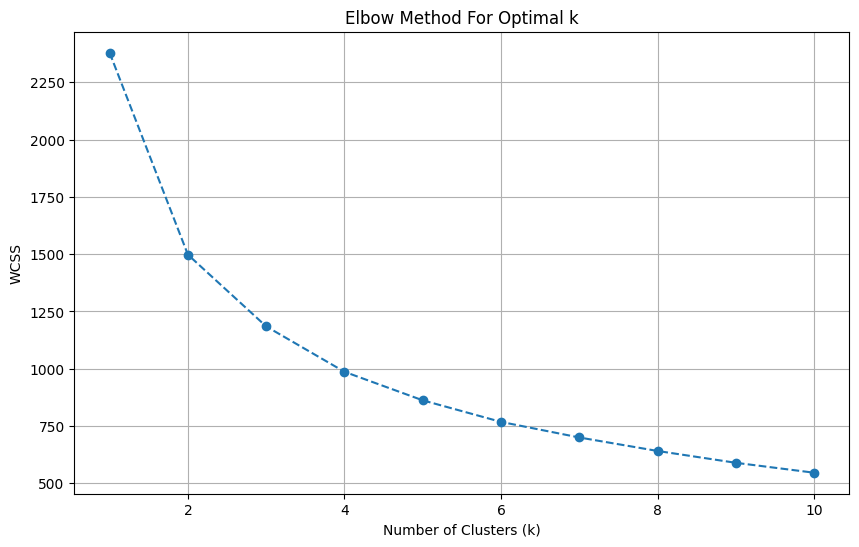

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Try different number of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### 6. Apply K-Means Clustering

Based on the Elbow Method, we'll choose **4** as the optimal number of clusters. Now, we apply the K-Means algorithm to the scaled RFM data (`rfm_scaled_df`) to segment our customers into these 4 groups.

In [8]:
from sklearn.cluster import KMeans

# Initialize KMeans with the optimal number of clusters (k=4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit KMeans to the scaled RFM data and get cluster labels
clusters = kmeans.fit_predict(rfm_scaled_df)

# Add the cluster labels to the original RFM DataFrame
rfm['Cluster'] = clusters

# Display the first few rows of the RFM DataFrame with cluster labels
display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,184,5,5563.560,1
1,AA-10375,19,9,1056.390,2
2,AA-10480,259,4,1790.512,1
3,AA-10645,55,6,5086.935,0
4,AB-10015,415,3,886.156,3


### 7. Analyze Customer Segments

Now that customers have been segmented into 4 clusters, we need to analyze the characteristics of each cluster. By calculating the mean Recency, Frequency, and Monetary values for each segment, we can understand their behavior and describe them in business terms.

In [9]:
# Calculate mean RFM values for each cluster
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# Sort by Monetary value to get a better overview (optional)
cluster_profiles.sort_values(by='Monetary', ascending=False, inplace=True)

display(cluster_profiles)

,Cluster,Recency,Frequency,Monetary
0,0,88.293436,8.501931,4928.351804
2,2,17.179775,6.808989,2532.102034
1,1,225.694030,5.104478,1969.241202
3,3,340.931818,2.579545,480.533395


# 8. Mean Recency, Frequency, and Monetary

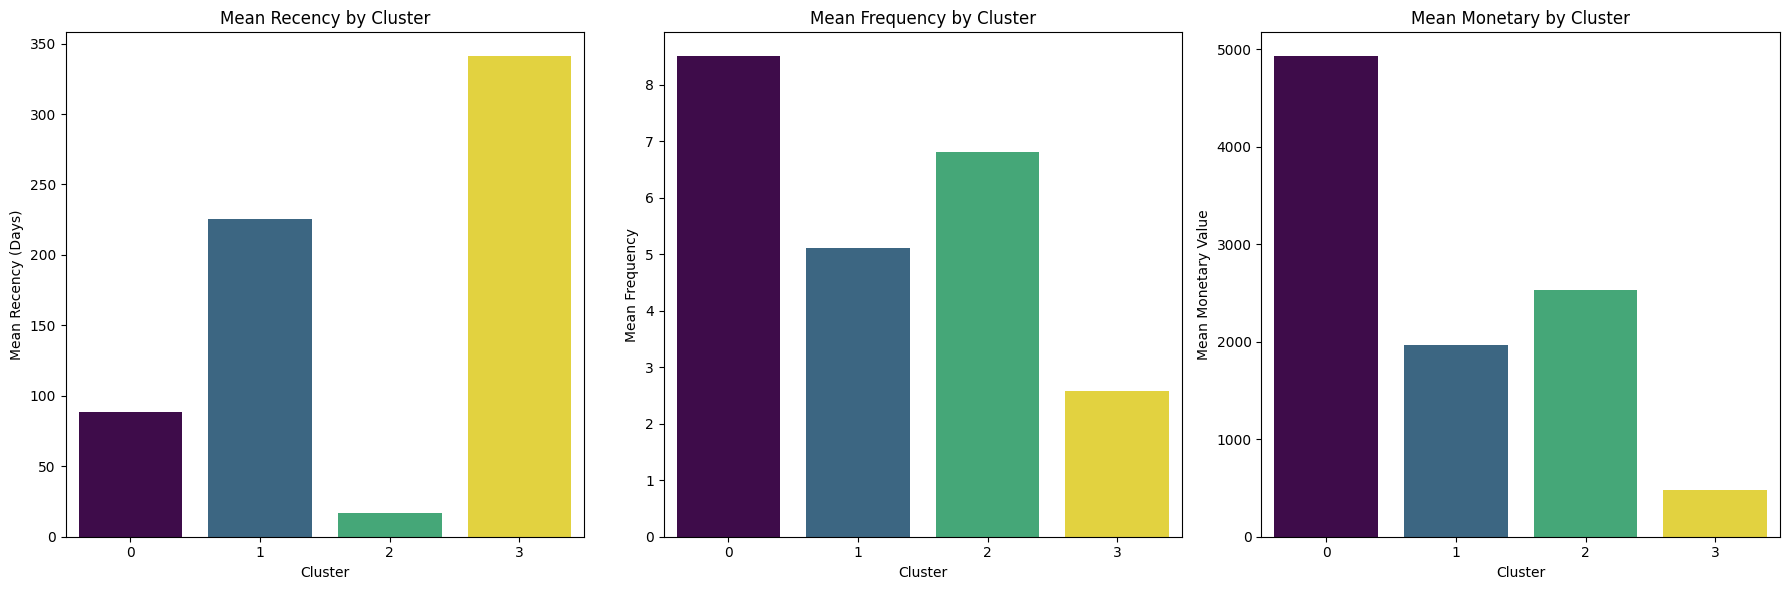

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Plot Recency
sns.barplot(x='Cluster', y='Recency', data=cluster_profiles, ax=axes[0], hue='Cluster', palette='viridis', legend=False)
axes[0].set_title('Mean Recency by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Mean Recency (Days)')

# Plot Frequency
sns.barplot(x='Cluster', y='Frequency', data=cluster_profiles, ax=axes[1], hue='Cluster', palette='viridis', legend=False)
axes[1].set_title('Mean Frequency by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean Frequency')

# Plot Monetary
sns.barplot(x='Cluster', y='Monetary', data=cluster_profiles, ax=axes[2], hue='Cluster', palette='viridis', legend=False)
axes[2].set_title('Mean Monetary by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Mean Monetary Value')

plt.tight_layout()
plt.show()

# 9. Distribution of Customers Across Clusters

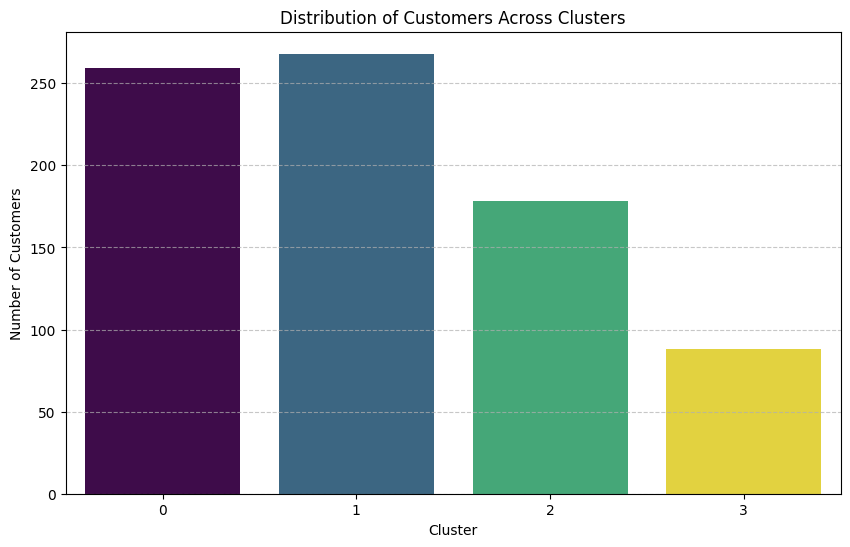

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Customer Count']

# Sort by Cluster number for better readability
cluster_counts = cluster_counts.sort_values(by='Cluster')

# Create a bar plot for customer distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='Customer Count', data=cluster_counts, hue='Cluster', palette='viridis', legend=False)
plt.title('Distribution of Customers Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 10. Distribution of Monetary Value Across Clusters

I will analyze the distribution of sales for each cluster by creating a box plot, which will visually represent the spread and central tendency of the 'Monetary' value within each customer segment.

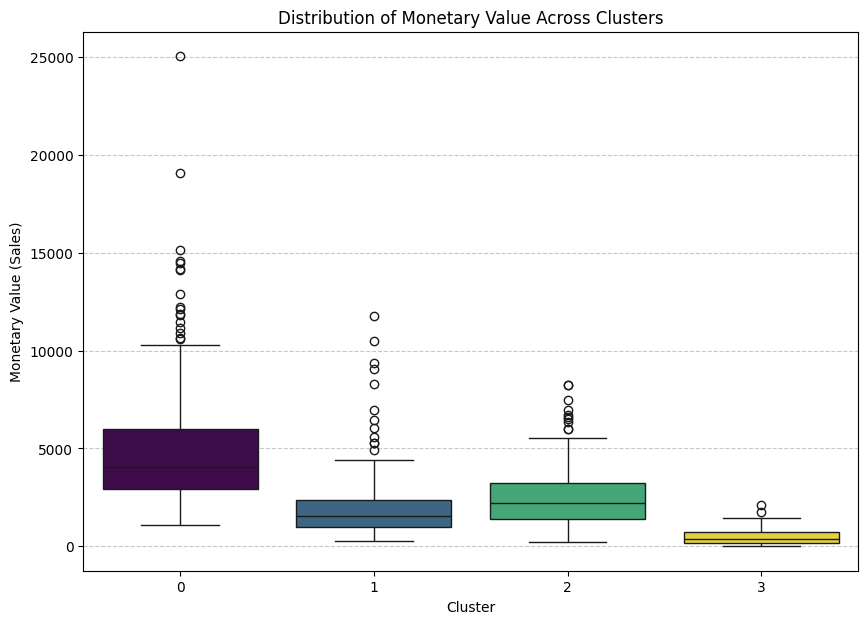

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='viridis', hue='Cluster', legend=False)
plt.title('Distribution of Monetary Value Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Monetary Value (Sales)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **11. Describing each customer segment in business terms** ##

**Cluster 0: High-Value, Frequent, and Recent Customers**

**Recency:** 88 days (relatively recent)

**Frequency:** 8.5 purchases (highest frequency)

**Monetary:** $4928 (highest monetary value)

**Description:** These are the **best customers**. They buy frequently, spend the most, and have made a purchase relatively recently. They are highly engaged and valuable to the business. Marketing strategies should focus on retention, loyalty programs, and premium offerings.

**Cluster 1: Loyal but Less Recent Customers**

**Recency:** 225 days (less recent)

**Frequency:** 5.1 purchases (moderate frequency)

**Monetary:** $1969 (moderate monetary value)

**Description:** These customers were once valuable but haven't purchased as recently as Cluster 0. They might be at risk of churning. Strategies could focus on re-engaging them with personalized offers, reminders, or win-back campaigns to prevent them from becoming completely inactive.

**Cluster 2: Recent and Moderate Spenders**

**Recency:** 17 days (most recent)

**Frequency:** 6.8 purchases (moderate frequency)

**Monetary:** $2532 (moderate monetary value)

**Description:** These are new or recently active customers who have made purchases very recently and show decent spending. They have high potential to become high-value customers with the right nurturing. Strategies could include onboarding programs, product recommendations, and incentives for repeat purchases.

**Cluster 3: Lapsed or Low-Value Customers**

**Recency:** 340 days (least recent)

**Frequency:** 2.5 purchases (lowest frequency)

**Monetary:** $480 (lowest monetary value)

**Description:** These customers have not purchased for a long time, buy infrequently, and spend the least. They are likely lapsed customers or one-time buyers. Re-engagement efforts might be less effective, or different strategies like targeted clearance sales or surveying for feedback could be considered, though ROI on these customers may be lower.

These descriptions provide actionable insights for tailoring marketing campaigns, improving customer service, and developing retention strategies for each distinct customer group.

### 12. Project Insights and Conclusion

By applying RFM analysis and K-Means clustering, we successfully segmented the customer base into four distinct groups, each with unique characteristics and value to the business:

*   **Cluster 0: High-Value, Frequent, and Recent Customers (Best Customers)**
    *   **Characteristics:** These customers have the highest monetary value, purchase frequently, and have made recent purchases. They are the most valuable segment.
    *   **Strategy:** Focus on retention, loyalty programs, exclusive offers, and personalized communication to maintain their engagement and encourage repeat high-value purchases.

*   **Cluster 1: Loyal but Less Recent Customers (At-Risk of Churning)**
    *   **Characteristics:** These customers have high frequency and monetary value but their last purchase was a while ago. They are at risk of churning.
    *   **Strategy:** Implement re-engagement campaigns, special discounts to encourage reactivation, and personalized win-back offers.

*   **Cluster 2: Recent and Moderate Spenders (New/Recently Active, High Potential)**
    *   **Characteristics:** Customers in this segment have made recent purchases and show moderate frequency and monetary value. They might be new customers or those just starting to engage.
    *   **Strategy:** Nurture these customers with onboarding programs, product recommendations, and incentives to increase their frequency and monetary value, aiming to move them to the 'Best Customers' segment.

*   **Cluster 3: Lapsed or Low-Value Customers (Lapsed/One-time Buyers)**
    *   **Characteristics:** This segment consists of customers with low recency, frequency, and monetary value. They might be one-time buyers or customers who have not purchased in a long time.
    *   **Strategy:** Limited investment. Consider targeted campaigns for reactivation with deep discounts, or focus efforts on other segments. Understand why they are low-value to improve future acquisition strategies.

**Conclusion:**

This customer segmentation project provides a clear, actionable framework for understanding and targeting different customer groups. By customizing marketing strategies and interventions for each segment, the business can:

*   **Optimize Marketing Spend:** Allocate resources more effectively by focusing on high-value and high-potential segments.
*   **Improve Customer Retention:** Identify at-risk customers and implement timely re-engagement strategies.
*   **Enhance Customer Lifetime Value (CLTV):** Develop programs to move customers up the value ladder from 'New' to 'Best Customers'.
*   **Increase ROI:** Tailored approaches are more likely to resonate with specific customer needs, leading to higher conversion rates and improved business outcomes.

This analysis serves as a foundational step for data-driven decision-making in customer relationship management.